In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing (basic)
import re
from collections import Counter

%matplotlib inline

In [4]:
df=pd.read_csv('../data/yelp.csv')

In [5]:
#eda
df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,1/26/2011,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,7/27/2011,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,6/14/2012,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,5/27/2010,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,1/5/2012,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [6]:
df.shape

(10000, 10)

In [7]:
df.columns

Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   business_id  10000 non-null  str  
 1   date         10000 non-null  str  
 2   review_id    10000 non-null  str  
 3   stars        10000 non-null  int64
 4   text         10000 non-null  str  
 5   type         10000 non-null  str  
 6   user_id      10000 non-null  str  
 7   cool         10000 non-null  int64
 8   useful       10000 non-null  int64
 9   funny        10000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 781.4 KB


In [9]:
df.type.unique()

<StringArray>
['review']
Length: 1, dtype: str

In [10]:
#checking for null values
df.isnull().sum()

business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64

lets move on to FEATURE CREATION as there is no fake review in the dataset and we have to create one by ourselves. 
We will be using the 'text' column to create a new feature called 'review_length' which will represent the length of each review in 
terms of number of characters. This feature can help us identify potential fake reviews, as they may tend to be shorter
 or longer than genuine reviews.


In [11]:
df['review_length'] = df['text'].apply(len)
df['engagement'] = df['cool'] + df['useful'] + df['funny']

In [12]:
df.head(2)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,review_length,engagement
0,9yKzy9PApeiPPOUJEtnvkg,1/26/2011,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889,7
1,ZRJwVLyzEJq1VAihDhYiow,7/27/2011,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,1345,0


Step 1: Summary Statistics
Step 2: Distribution Plots
Step 3: Key Patterns -check relationships

In [13]:
df[['review_length', 'stars', 'engagement']].describe()

,review_length,stars,engagement
count,10000.000000,10000.000000,10000.000000
mean,710.738700,3.777500,2.987400
std,617.399827,1.214636,5.867732
min,1.000000,1.000000,0.000000
25%,294.000000,3.000000,0.000000
50%,541.500000,4.000000,1.000000
75%,930.000000,5.000000,3.000000
max,4997.000000,5.000000,153.000000


 Review Length
Are reviews mostly short or long?
Any extreme values?
 Stars
Mostly 4–5? (common in Yelp)
Any imbalance?
 Engagement
Many zeros? (very important signal)
Some very high values?

Text(0.5, 1.0, 'Review Length Distribution')

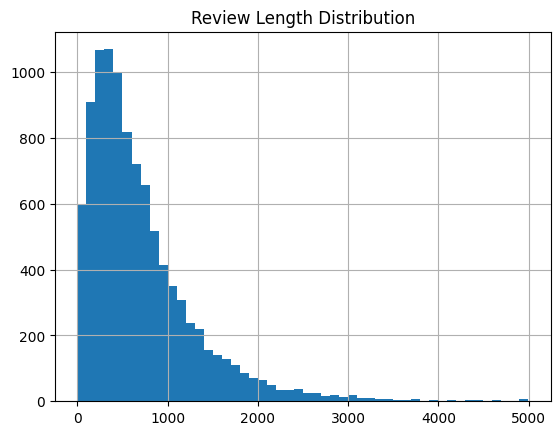

In [14]:
#distribution plots
df['review_length'].hist(bins=50)
# review_length = number of characters in each review
# bins=50 = divide data into 50 groups
plt.title("Review Length Distribution")
#X-axis → review length (number of characters)  , Y-axis → number of reviews

### Observations:
Most reviews are short (0–1000 characters)
As length increases → number of reviews drops sharply
Very few reviews are extremely long (3000–5000)

Text(0.5, 1.0, 'Star Rating Distribution')

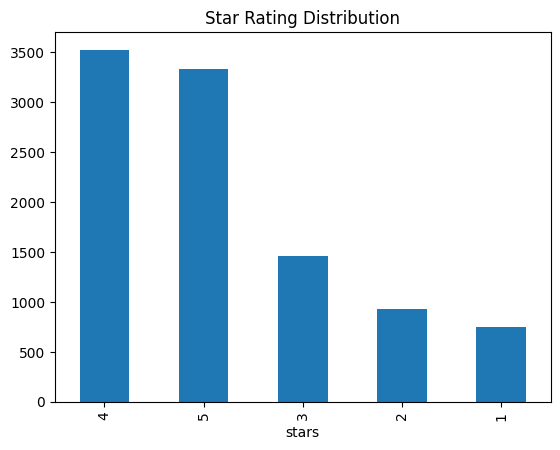

In [15]:
df['stars'].value_counts().plot(kind='bar')
plt.title("Star Rating Distribution")

### Observations: Star Rating Distribution

- Most reviews are 4-star and 5-star ratings  
- Very few reviews are 1-star and 2-star  
- The distribution is heavily skewed toward positive ratings  
- This indicates a strong positivity bias in user reviews  

- Extremely positive reviews (especially 5-star) may include fake or promotional content  
- Low-rated reviews are fewer but are often more detailed and potentially more genuine  

Text(0.5, 1.0, 'Engagement Distribution')

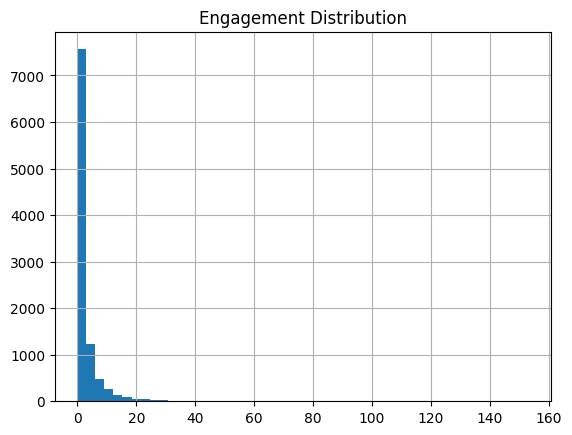

In [16]:
# Plot histogram of engagement (cool + useful + funny)
# Engagement represents how much interaction a review receives from users
# bins=50 helps visualize how engagement values are distributed
df['engagement'].hist(bins=50)
plt.title("Engagement Distribution")

### Observations: Engagement Distribution

- Most reviews have very low engagement (close to 0)
- A small number of reviews have high engagement
- The distribution is highly right-skewed
- This indicates that only a few reviews receive significant attention

- Reviews with zero or very low engagement may be less trustworthy or ignored
- Highly engaged reviews are rare and may indicate genuine or impactful content

### Suspicious pattern:
The engagement distribution is highly skewed, with most reviews receiving little to no interaction. This is useful for detecting anomalies, as highly positive reviews with low engagement may indicate suspicious or low-credibility content.

### 3 insights:
Review length → mostly short
Stars → mostly positive
Engagement → mostly low

### Feature Engineering
Step 1: Create all features
Step 2: Create improved suspicious score
Step 3: Check distribution
Step 4: Inspect suspicious reviews


In [ ]:
# Length of each review (number of characters)
df['review_length'] = df['text'].apply(len)

# Number of words in each review
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Average word length (avoid division by zero using +1)
df['avg_word_length'] = df['review_length'] / (df['word_count'] + 1)

# Engagement = cool + useful + funny
df['engagement'] = df['cool'] + df['useful'] + df['funny']

# Engagement ratio normalized by review length
# High ratio → strong engagement relative to length
# Low ratio → weak or no engagement (potentially suspicious)

# Example:
# Case 1:
# Review length = 500, engagement = 2
# → Very long review but very low interaction → suspicious

# Case 2:
# Review length = 50, engagement = 2
# → Short review with same engagement → more meaningful
df['engagement_ratio'] = df['engagement'] / (df['review_length'] + 1)

# Convert star ratings into a binary feature:
# 1-star and 5-star → 1 (extreme ratings)
# 2, 3, 4-star → 0 (normal ratings)
df['extreme_rating'] = df['stars'].apply(lambda x: 1 if x in [1, 5] else 0)

In [ ]:
# Create a suspicious score by combining multiple signals:
# short review, low word count, no engagement, and extreme rating
# Each condition adds 1 → higher total score = more suspicious review
df['suspicious_score_v2'] = (
    (df['review_length'] < 50).astype(int) +   # very short review
    (df['word_count'] < 10).astype(int) +      # very few words
    (df['engagement'] == 0).astype(int) +      # no engagement
    (df['extreme_rating']).astype(int)         # extreme rating
)

In [21]:
df['suspicious_score_v2'].value_counts()

# Most reviews (scores 0 and 1) are normal
# Some reviews (score 2) show moderate suspicious behavior
# Very few reviews (scores 3 and 4) are highly suspicious and likely anomalies

suspicious_score_v2
1    4581
0    3760
2    1474
3     111
4      74
Name: count, dtype: int64

In [23]:
df.head(1)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,review_length,engagement,word_count,avg_word_length,engagement_ratio,extreme_rating,suspicious_score_v2
0,9yKzy9PApeiPPOUJEtnvkg,1/26/2011,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889,7,155,5.698718,0.007865,1,1


In [20]:
df[df['suspicious_score_v2'] >= 3][['text', 'stars', 'engagement']].head(10)

,text,stars,engagement
95,Awesome subs clean and friendly well priced.,5,2
127,Very friendly and knowledgeable guys.,5,0
165,This place is not there anymore.,1,4
175,Good pizza. Nice and laid back. Good staff too.,4,0
217,Love Krista!,5,2
253,Love this location at Gainey Ranch! Great food...,5,0
254,Our server Gary was awesome. Food was amazing....,5,0
266,"Excellent New Mexico style food, great hatch g...",5,0
284,Great service,5,1
342,"Bad service, great food, awful coffee.",3,0


### Observations: Suspicious Reviews

- Reviews with high suspicious scores are typically very short
- Many have extreme ratings (1-star or 5-star)
- Most have zero engagement from other users
- The text often appears generic and low-effort

This supports the assumption that such reviews may be fake or less trustworthy.

interview:
“I normalized engagement with respect to review length to capture relative user interaction, and created an extreme rating flag since fake reviews tend to exhibit highly polarized ratings.”

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   business_id          10000 non-null  str    
 1   date                 10000 non-null  str    
 2   review_id            10000 non-null  str    
 3   stars                10000 non-null  int64  
 4   text                 10000 non-null  str    
 5   type                 10000 non-null  str    
 6   user_id              10000 non-null  str    
 7   cool                 10000 non-null  int64  
 8   useful               10000 non-null  int64  
 9   funny                10000 non-null  int64  
 10  review_length        10000 non-null  int64  
 11  engagement           10000 non-null  int64  
 12  word_count           10000 non-null  int64  
 13  avg_word_length      10000 non-null  float64
 14  engagement_ratio     10000 non-null  float64
 15  extreme_rating       10000 non-null  int64  
 16

### MODEL BUILDING
Step 1: Prepare features and target

Step 2: Split data into train and test sets

Step 3: Preprocessing and model setup

Step 4: Train models and evaluate

Step 5: Feature importance & hybrid scoring
For tree-based models like Decision Tree or Random Forest, we can see which features are driving predictions. Then we can combine ML probability with your rule-based suspicious score for a hybrid anomaly score.

Step 6: Threshold tuning / binning hybrid score
Now that we have a hybrid_score (combining rule-based + ML probability), we need to decide what counts as normal vs suspicious or even low/mid/high suspicion.

In [26]:
# Prepare features and target for modeling
import pandas as pd

# Numeric features
numeric_features = ['stars', 'cool', 'useful', 'funny',
                    'review_length', 'engagement', 'word_count',
                    'avg_word_length', 'engagement_ratio', 'extreme_rating']

# Categorical features
categorical_features = ['type']

# Convert suspicious_score_v2 to binary: 0,1 = normal (0), 2+ = suspicious (1)
df['suspicious_binary'] = df['suspicious_score_v2'].apply(lambda x: 0 if x <= 1 else 1)

# Target
y = df['suspicious_binary']

# Features (drop IDs)
X = df[numeric_features + categorical_features]

print("Features and target prepared!")
X.head()

Features and target prepared!


,stars,cool,useful,funny,review_length,engagement,word_count,avg_word_length,engagement_ratio,extreme_rating,type
0,5,2,5,0,889,7,155,5.698718,0.007865,1,review
1,5,0,0,0,1345,0,257,5.213178,0.000000,1,review
2,4,0,1,0,76,1,16,4.470588,0.012987,0,review
3,5,1,2,0,419,3,76,5.441558,0.007143,1,review
4,5,0,0,0,469,0,86,5.390805,0.000000,1,review


In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
#random_state=42 → Ensures the split is the same every time (ensures reproducible results).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train and test sets created!")
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Train and test sets created!
Training samples: 8000, Testing samples: 2000


In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

print(" models are ready!")

 models are ready!


## Step 3: Preprocessing + Model Setup

**Purpose:**  
Prepare the data and define ML models so they can be trained.

**Key Points:**
1. **Preprocessing**
   - **Numeric features** → kept as-is.
   - **Categorical features** → converted to numbers using **One-Hot Encoding** (drop='first' avoids dummy variable trap).
   as the type is the only categorical value and contains only 1 unique value whic is review -> it is better to remove preprocessing

2. **Models**
   - **Logistic Regression** → simple, interpretable linear model.
   - **Decision Tree** → splits data based on feature thresholds, easy to visualize.
   - **Random Forest** → ensemble of trees, reduces overfitting, more accurate.

3. **Pipeline** (later) combines preprocessing + model into one workflow.


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1672
           1       0.98      0.92      0.95       328

    accuracy                           0.98      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.98      0.98      0.98      2000



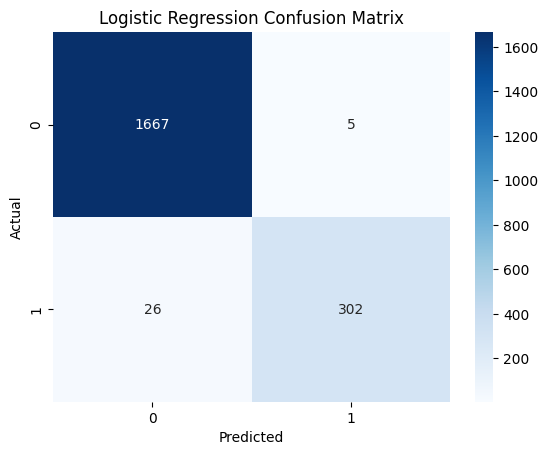


===== Decision Tree =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1672
           1       1.00      1.00      1.00       328

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



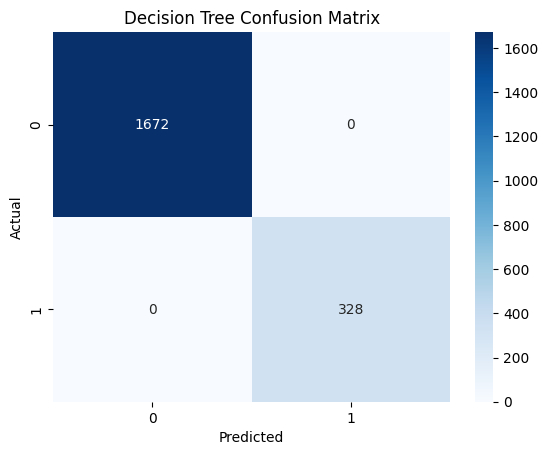


===== Random Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1672
           1       1.00      1.00      1.00       328

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



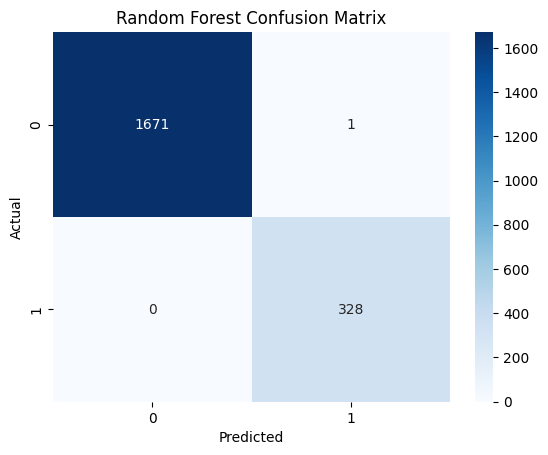

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    # Create a pipeline: preprocessing + model
    pipe = Pipeline(steps=[('preprocessor'),
                           ('classifier', model)])
    
    # Train the model
    pipe.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = pipe.predict(X_test)
    
    # Evaluation
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    

fit means feeding the data to model 

predict means seeing how well the trained model will perform

## Model Evaluation Summary

### Logistic Regression
- **Accuracy:** 0.98  
- **Precision (suspicious):** 0.98  
- **Recall (suspicious):** 0.92  
- **F1-score (suspicious):** 0.95  
- **Interpretation:** Good performance, but misses some suspicious reviews.  

### Decision Tree
- **Accuracy:** 1.00  
- **Precision / Recall / F1-score:** 1.00  
- **Interpretation:** Perfect classification on test data; may overfit on training patterns.  

### Random Forest
- **Accuracy:** 1.00  
- **Precision / Recall / F1-score:** 1.00  
- **Interpretation:** Perfect classification, more robust than a single tree.  

### Key Takeaways
1. Numeric features alone are sufficient for classification.  
2. Decision Tree / Random Forest capture patterns strongly; Logistic Regression is slightly weaker but interpretable.  
3. Models are ready to generate probabilities for hybrid scoring in the next step.

In [ ]:
# ----------------------------
# Step 5: Hybrid Score
# ----------------------------
# Use Random Forest from Step 4 (assume we pick the trained one from models dict)
rf_model = models['Random Forest']

# If using pipeline with preprocessing:
rf_pipe = Pipeline(steps=[('preprocessor'),
                          ('classifier', rf_model)])
rf_pipe.fit(X_train, y_train)  # ensure it's trained on current train set

# 1️⃣ Get model probability for suspicious class
ml_probs = rf_pipe.predict_proba(X)[:, 1]  # probability of being suspicious

# 2️⃣ Combine with rule-based score (0-4)
# Weighted combination: 50% rule, 50% model
df['hybrid_score'] = 0.5 * df['suspicious_score_v2'] + 0.5 * ml_probs

# Preview
df[['suspicious_score_v2', 'hybrid_score']].head()

,suspicious_score_v2,hybrid_score
0,1,0.5
1,2,1.5
2,0,0.0
3,1,0.5
4,2,1.5


### Step 5: Hybrid Score 

- **Model choice:** We use the **Random Forest** since it performs best for anomaly detection.  
- **Pipeline:** Recreate a pipeline with preprocessing to handle categorical features (if any) and fit it on training data.  
- **Probabilities:** `predict_proba(X)[:,1]` gives the probability of each review being suspicious.  
- **Hybrid score:**
Combines rule-based score (suspicious_score_v2) and ML probability.
Weighted equally: 50% rule, 50% model.
The result is a hybrid score, which is continuous, not just 0/1. 
- **Result:** A continuous **hybrid score** that balances rules and ML predictions, capturing nuanced cases better than 0/1 labels.

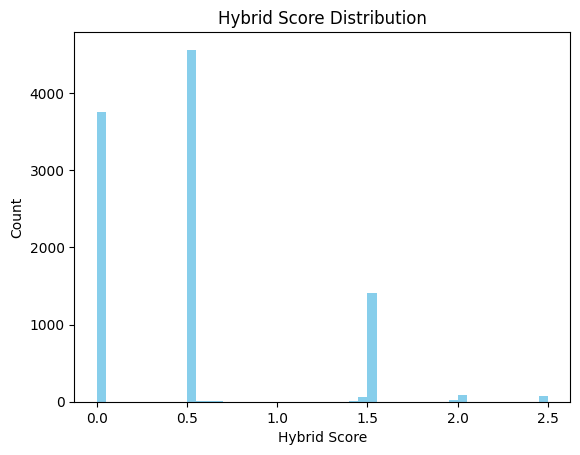

,suspicious_score_v2,hybrid_score,hybrid_label
0,1,0.5,0
1,2,1.5,1
2,0,0.0,0
3,1,0.5,0
4,2,1.5,1
5,0,0.0,0
6,1,0.5,0
7,0,0.0,0
8,1,0.5,0
9,1,0.5,0


In [31]:
import numpy as np

# Example: 3-level binning
# 0 = Normal, 1 = Mildly suspicious, 2 = Highly suspicious
# You can tweak thresholds based on your dataset distribution

# Inspect hybrid score distribution
import matplotlib.pyplot as plt
plt.hist(df['hybrid_score'], bins=50, color='skyblue')
plt.title('Hybrid Score Distribution')
plt.xlabel('Hybrid Score')
plt.ylabel('Count')
plt.show()

# Define thresholds (example)
threshold_low = 0.5
threshold_high = 1.5

def categorize_hybrid(score):
    if score <= threshold_low:
        return 0  # Normal
    elif score <= threshold_high:
        return 1  # Mildly suspicious
    else:
        return 2  # Highly suspicious

df['hybrid_label'] = df['hybrid_score'].apply(categorize_hybrid)

# Quick check
df[['suspicious_score_v2', 'hybrid_score', 'hybrid_label']].head(10)

### Agentic AI Layer – Overview

Goal: Automatically decide actions for each review based on the hybrid score (combination of rule-based and ML model).

Steps:

1.Define Thresholds & Labels

    0–1 → Normal

    2 → Mildly suspicious

    3–4 → Highly suspicious

2.Assign Hybrid Labels

    Convert continuous hybrid scores into discrete labels using the thresholds.

3.Agentic Decision Function

    Map each label to an action:

    Normal: No action

    Mildly suspicious: Flag for manual review

    Highly suspicious: Hide review & alert moderator

4.Apply Decisions to Dataset

    Each review gets an automatic action assigned.

5.Optional Enhancements

    Store actions in a database

    Trigger alerts or notifications

    Later, add a feedback loop to improve decisions over time

Result: Reviews are automatically categorized and actions assigned, making the system partially autonomous.

In [36]:
df.head(1)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,review_length,engagement,word_count,avg_word_length,engagement_ratio,extreme_rating,suspicious_score_v2,suspicious_binary,hybrid_score,hybrid_label
0,9yKzy9PApeiPPOUJEtnvkg,1/26/2011,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889,7,155,5.698718,0.007865,1,1,0,0.5,0


In [38]:
df.hybrid_label.unique()

array([0, 1, 2])

In [39]:
# ----------------------------
# 1️⃣ Define thresholds and hybrid labels
# ----------------------------
def categorize_hybrid(score):
    if score <= 1:
        return 0  # Normal
    elif score == 2:
        return 1  # Mildly suspicious
    else:  # 3-4
        return 2  # Highly suspicious

df['hybrid_label'] = df['hybrid_score'].apply(categorize_hybrid)

In [42]:
# ----------------------------
# 2️⃣ Define Agentic actions
# ----------------------------
def agentic_decision(hybrid_label, review_id=None):
    if hybrid_label == 0:
        return "No action"
    elif hybrid_label == 1:
        return "Flag for manual review"
    else:  # hybrid_label == 2
        return "Hide review & alert moderator"

df['agentic_action'] = df['hybrid_label'].apply(agentic_decision)

### analysis and visualization
analyze and visualize the results from your Agentic AI layer to see how reviews are distributed across action categories.

agentic_action
No action                        8341
Hide review & alert moderator    1575
Flag for manual review             84
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10584\89565827.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.index, y=action_counts.values, palette="coolwarm")


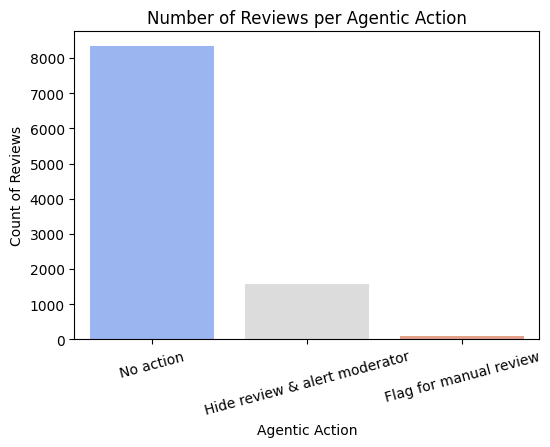

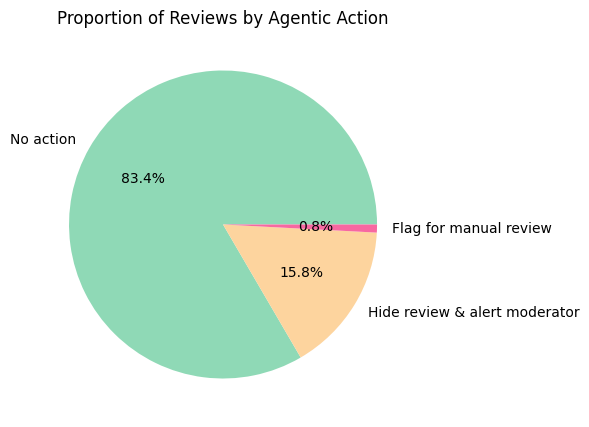

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of reviews per agentic action
action_counts = df['agentic_action'].value_counts()
print(action_counts)

# Bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=action_counts.index, y=action_counts.values, palette="coolwarm")
plt.title("Number of Reviews per Agentic Action")
plt.ylabel("Count of Reviews")
plt.xlabel("Agentic Action")
plt.xticks(rotation=15)
plt.show()

# Optional: Pie chart for proportion
plt.figure(figsize=(5,5))
plt.pie(action_counts.values, labels=action_counts.index, autopct='%1.1f%%', colors=['#8fd9b6','#fdd49e','#f768a1'])
plt.title("Proportion of Reviews by Agentic Action")
plt.show()

### Preparing the data for backend integration

In [46]:
# Select relevant columns for backend
backend_data = df[[
    'review_id',         # Unique review identifier
    'user_id',           # Who wrote the review
    'business_id',       # Which business this review belongs to
    'stars',             # Original rating
    'suspicious_score_v2', # Rule-based score
    'hybrid_score',      # Combined ML + rule score
    'hybrid_label',      # 0 = Normal, 1 = Mildly suspicious, 2 = Highly suspicious
    'agentic_action'     # Action decided by Agentic AI
]]

# Optional: reset index for cleaner export
backend_data.reset_index(drop=True, inplace=True)

# Preview the prepared data
backend_data.head()

,review_id,user_id,business_id,stars,suspicious_score_v2,hybrid_score,hybrid_label,agentic_action
0,fWKvX83p0-ka4JS3dc6E5A,rLtl8ZkDX5vH5nAx9C3q5Q,9yKzy9PApeiPPOUJEtnvkg,5,1,0.5,0,No action
1,IjZ33sJrzXqU-0X6U8NwyA,0a2KyEL0d3Yb1V6aivbIuQ,ZRJwVLyzEJq1VAihDhYiow,5,2,1.5,2,Hide review & alert moderator
2,IESLBzqUCLdSzSqm0eCSxQ,0hT2KtfLiobPvh6cDC8JQg,6oRAC4uyJCsJl1X0WZpVSA,4,0,0.0,0,No action
3,G-WvGaISbqqaMHlNnByodA,uZetl9T0NcROGOyFfughhg,_1QQZuf4zZOyFCvXc0o6Vg,5,1,0.5,0,No action
4,1uJFq2r5QfJG_6ExMRCaGw,vYmM4KTsC8ZfQBg-j5MWkw,6ozycU1RpktNG2-1BroVtw,5,2,1.5,2,Hide review & alert moderator


In [47]:
# Export to CSV for now
backend_data.to_csv('agentic_ai_ready.csv', index=False)